In [6]:
import numpy as np
import simulate_data as sim 
from gwas import gwas_linear, gwas_probit

n, d = 1_000, 200
k = 10
corr = 0.7
rho = 0.5
snr_s = 1
snr_y = 2
pi_s =0.1
pi_y = 0.05
p_sel = 0.3


rng=np.random.default_rng(42)
X = sim.X_corr_blocks(n, d, k, corr, intercept=True, rng=rng)

data = sim.simulate_heckman(X, rho, snr_s, snr_y, pi_s, pi_y, p_sel, rng=rng)
s = data["s"]
y = data["y"]
beta_s = data["beta_s"]
beta_y = data["beta_y"]


b_s = gwas_probit(X, s)[0] / np.sqrt(len(s))
b_y = gwas_linear(X, y)[0] / np.sqrt(s.sum())

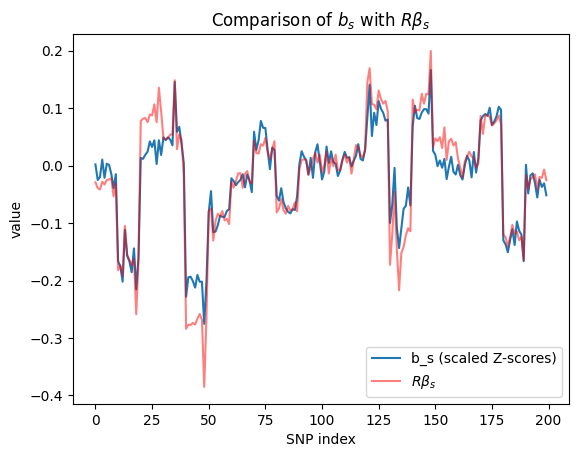

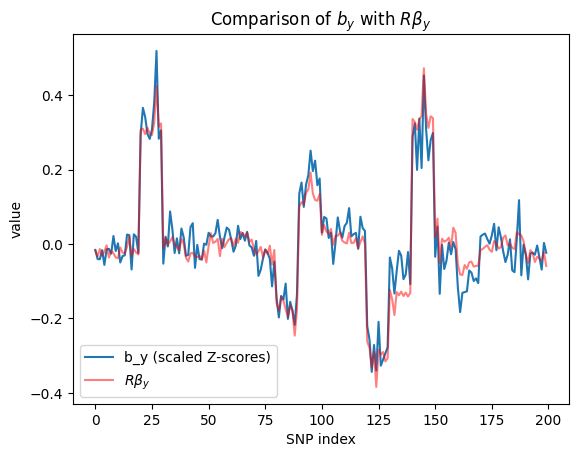

In [7]:
import matplotlib.pyplot as plt

R = np.corrcoef(X[:, 1:], rowvar=False)
plt.plot(b_s[1:], label="b_s (scaled Z-scores)")
plt.plot(R @ beta_s[1:], color="red", alpha=0.5, label=r"$R \beta_s$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_s$ with $R\beta_s$")
plt.show()


plt.plot(b_y[1:], label="b_y (scaled Z-scores)")
plt.plot(R @ beta_y[1:], color="red", alpha=0.5, label=r"$R \beta_y$")
plt.legend()
plt.xlabel("SNP index")
plt.ylabel("value")
plt.title(r"Comparison of $b_y$ with $R\beta_y$")
plt.show()

In [11]:
import numpy as np

def simulate_block_correlation_matrix(d, k, corr, within_diag=1.0):
    """
    Parameters
    ----------
    d : int
        Total matrix dimension.
    k : int
        Block size.
    corr : float
        Within-block correlation strength, must be in (-1, 1).
    within_diag : float, optional
        Diagonal value (default 1.0).

    Returns
    -------
    R : ndarray (d, d)
        Simulated block-correlated matrix.
    """
    R = np.zeros((d, d))

    start = 0
    while start < d:
        end = min(start + k, d)
        block_size = end - start
        block = np.full((block_size, block_size), corr)
        np.fill_diagonal(block, within_diag)
        R[start:end, start:end] = block
        start = end

    return R

def simulate_design_matrix(n, R):
    """Simulate an (n, d+1) design matrix: intercept + n samples ~ N(0, R)."""
    X = np.random.multivariate_normal(np.zeros(R.shape[0]), R, size=n)
    return np.column_stack([np.ones(n), X])


def var_from_snr(snr):
    """
    we assume Var(y*), Var(s*) = 1
    """
    var_signal = snr / (1 + snr)
    var_noise  = 1 / (1 + snr)    

    return var_signal, var_noise
    
def sparse_beta(pi0, p, var_target):
    k = max(1, int(round(pi0 * p)))
    beta = np.zeros(p)
    idx = rng.choice(p, size=k, replace=False)
    beta[idx] = rng.normal(size=k)

    signal = X @ beta
    signal = signal - signal.mean()  # center the signal
    scale = np.sqrt(var_target / signal.var())
    beta = beta * scale
    signal = signal * scale
    return beta, signal

def heckman_outcome(X, beta_s, beta_y, var_noise_s, var_noise_y, rho=0.0, rng=None):
    """
    Simulate Heckman selection model outcomes given existing X, beta_s, beta_y.

    Selection equation: s* = X @ beta_s + eps_s
    Outcome equation:   y* = X @ beta_y + eps_y
    eps_s, eps_y are jointly normal with correlation rho — this correlation
    is what induces the selection bias.

    Returns:
        s        : binary selection indicator (n,)
        y        : observed outcome, NaN where s == 0
        s_star   : latent selection variable (for diagnostics)
        y_star   : latent outcome variable (for diagnostics)
    """
    if rng is None:
        rng = np.random.default_rng()

    n = X.shape[0]

    # joint covariance of the error terms
    cov = rho * np.sqrt(var_noise_s * var_noise_y)
    Sigma = np.array([[var_noise_s, cov],
                       [cov,         var_noise_y]])

    eps = rng.multivariate_normal(np.zeros(2), Sigma, size=n)
    eps_s, eps_y = eps[:, 0], eps[:, 1]

    s_star = X @ beta_s + eps_s
    y_star = X @ beta_y + eps_y

    s = (s_star > 0).astype(int)
    y = np.where(s == 1, y_star, np.nan)

    return s, y, s_star, y_star
    
    


In [13]:
# 1. design matrix, shared between both equations
X = simulate_design_matrix(n, R)

# 2. noise variances derived from SNR (assumes Var(y*) = Var(s*) = 1)
var_signal_s, var_noise_s = var_from_snr(snr_s)
var_signal_y, var_noise_y = var_from_snr(snr_y)

# 3. sparse betas scaled to hit the target signal variance
beta_s, signal_s = sparse_beta(pi_s, d+1, var_signal_s)
beta_y, signal_y = sparse_beta(pi_y, d+1, var_signal_y)

# 4. correlated errors drive the selection bias
s, y, s_star, y_star = heckman_outcome(X, beta_s, beta_y, var_noise_s, var_noise_y, rho=0.5)